# LAB 9 - Randomized Forest Project Display:-

For this project we will be exploring publicly available data from [LendingClub.com](https://www.lendingclub.com/). Lending Club connects people who need money (borrowers) with people who have money (investors). Hopefully, as an investor you would want to invest in people who showed a profile of having a high probability of paying you back. We will try to create a model that will help predict this.

Lending club had a [very interesting year in 2016](https://en.wikipedia.org/wiki/Lending_Club#2016), so let's check out some of their data and keep the context in mind. This data is from before they even went public.

We will use lending data from 2007-2010 and be trying to classify and predict whether or not the borrower paid back their loan in full. You can use the csv already provided on Blackboard. The csv provided has been cleaned of NA values.

Here are what the columns represent:
* **credit.policy:** Flag indicating if the borrower meets LendingClub's specific underwriting standards (1 = Yes, 0 = No).

* **purpose:** The reason for the loan (e.g., debt consolidation, credit card, educational).

* **int.rate:** The interest rate assigned to the loan (represented as a decimal).

* **installment:** The borrower's monthly payment amount if the loan is approved.

* **log.annual.inc:** The natural logarithm of the borrower's reported yearly income.

* **dti:** The borrower's debt-to-income ratio.

* **fico:** The FICO credit score of the borrower.

* **days.with.cr.line:** Total days the borrower has maintained a credit line.

* **revol.bal:** Current balance on revolving accounts.

* **revol.util:** Utilization percentage of the revolving credit line.

* **inq.last.6mths:** Number of creditor inquiries within the last half-year.

* **delinq.2yrs:** Frequency of 30+ day delinquencies in the previous 2 years.

* **pub.rec:** Count of negative public records (e.g., bankruptcies, tax liens).

# Imported Libraries

**Import the usual libraries for pandas and plotting:**

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Fetching the Data

**Use pandas to read loan_data.csv as a dataframe called loans.**

In [62]:
loans = pd.read_csv('loan_data.csv')

**Check out the info(), head(), and describe() methods on loans.**

In [63]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [64]:
loans.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [65]:
loans.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


# Exploratory Data Analysis

Let's do some data visualization! We'll use seaborn and pandas built-in plotting capabilities.

**Create a histogram of two FICO distributions on top of each other, one for each credit.policy outcome.**

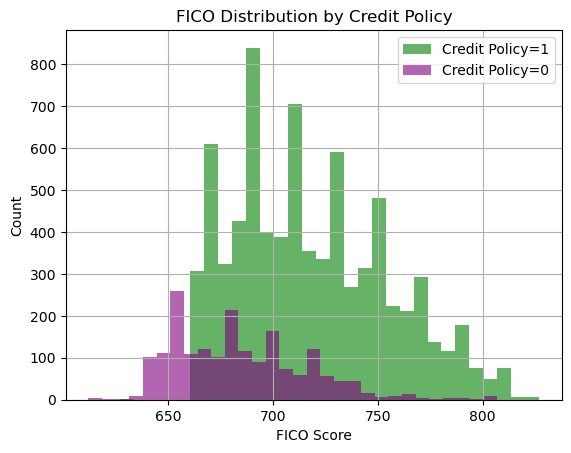

In [66]:
loans[loans['credit.policy']==1]['fico'].hist(bins=30, label='Credit Policy=1', color='green', alpha=0.6)
loans[loans['credit.policy']==0]['fico'].hist(bins=30, label='Credit Policy=0', color='purple', alpha=0.6)
plt.xlabel('FICO Score')
plt.ylabel('Count')
plt.title('FICO Distribution by Credit Policy')
plt.legend()
plt.show()

**Create a similar figure, except this time select by the not.fully.paid column.**

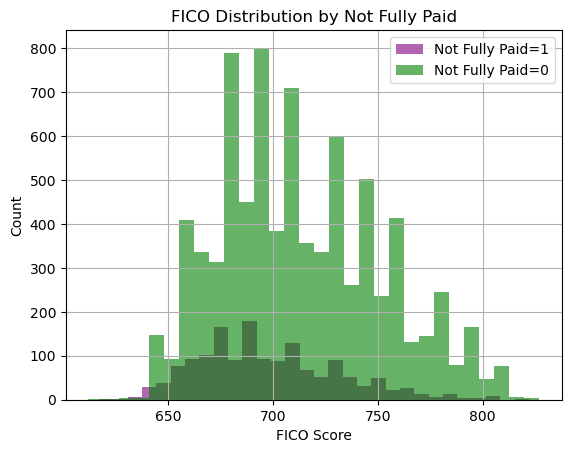

In [67]:
loans[loans['not.fully.paid']==1]['fico'].hist(bins=30, label='Not Fully Paid=1', color='purple', alpha=0.6)
loans[loans['not.fully.paid']==0]['fico'].hist(bins=30, label='Not Fully Paid=0', color='green', alpha=0.6)
plt.xlabel('FICO Score')
plt.ylabel('Count')
plt.title('FICO Distribution by Not Fully Paid')
plt.legend()
plt.show()

**Create a countplot using seaborn showing the counts of loans by purpose, with the color hue defined by not.fully.paid.**

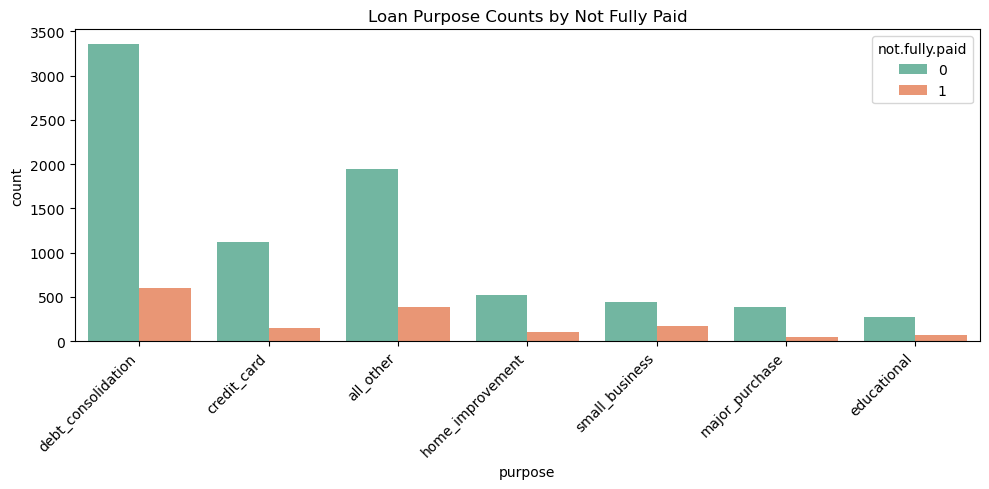

In [68]:
plt.figure(figsize=(10,5))
sns.countplot(x='purpose', hue='not.fully.paid', data=loans, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Loan Purpose Counts by Not Fully Paid')
plt.tight_layout()
plt.show()

**Let's see the trend between FICO score and interest rate. Recreate the following jointplot.**

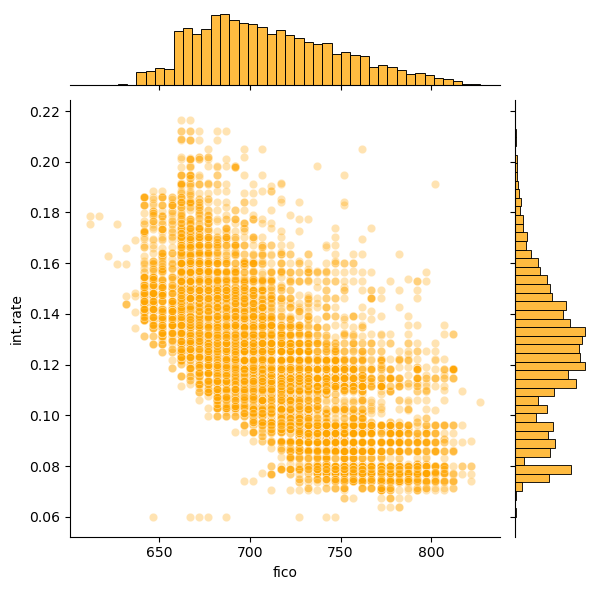

In [69]:
sns.jointplot(x='fico', y='int.rate', data=loans, color='orange', alpha=0.3)
plt.show()

**Create the following lmplots to see if the trend differed between not.fully.paid and credit.policy.**

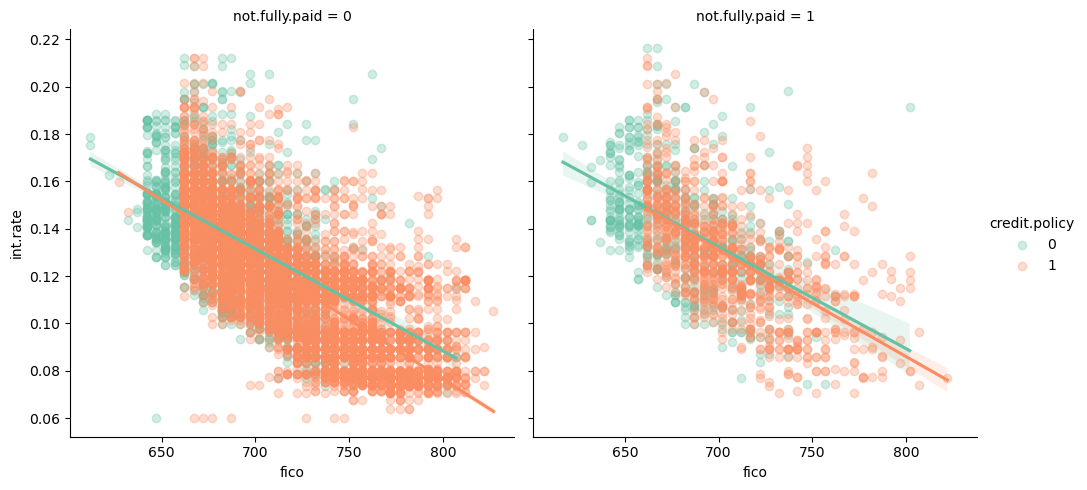

In [70]:
sns.lmplot(x='fico', y='int.rate', data=loans, hue='credit.policy', col='not.fully.paid', 
           palette='Set2', scatter_kws={'alpha':0.3})
plt.show()

# Setting up the Data

Let's get ready to set up our data for our Random Forest Classification Model!

**Check loans.info() again.**

In [71]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


## Categorical Features

Notice that the **purpose** column is categorical. We need to transform it using dummy variables so sklearn will be able to understand it.

**Create a list of 1 element containing the string 'purpose'. Call this list cat_feats.**

In [72]:
cat_feats = ['purpose']

**Now use pd.get_dummies to create a fixed larger dataframe. Set this dataframe as final_data.**

In [73]:
final_data = pd.get_dummies(loans, columns=cat_feats, drop_first=True)
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   credit.policy               9578 non-null   int64  
 1   int.rate                    9578 non-null   float64
 2   installment                 9578 non-null   float64
 3   log.annual.inc              9578 non-null   float64
 4   dti                         9578 non-null   float64
 5   fico                        9578 non-null   int64  
 6   days.with.cr.line           9578 non-null   float64
 7   revol.bal                   9578 non-null   int64  
 8   revol.util                  9578 non-null   float64
 9   inq.last.6mths              9578 non-null   int64  
 10  delinq.2yrs                 9578 non-null   int64  
 11  pub.rec                     9578 non-null   int64  
 12  not.fully.paid              9578 non-null   int64  
 13  purpose_credit_card         9578 

## Train Test Split

Now its time to split our data into a training set and a testing set!

In [74]:
from sklearn.model_selection import train_test_split

X = final_data.drop('not.fully.paid', axis=1)
y = final_data['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

## Training a Decision Tree Model

Let's start by training a single decision tree first!

In [75]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Predictions and Evaluation of Decision Tree

**Create predictions from the test set and create a classification report and a confusion matrix.**

In [76]:
from sklearn.metrics import classification_report, confusion_matrix

dt_predictions = dtree.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, dt_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      2431
           1       0.20      0.25      0.22       443

    accuracy                           0.73      2874
   macro avg       0.53      0.53      0.53      2874
weighted avg       0.76      0.73      0.74      2874


Confusion Matrix:
[[1996  435]
 [ 333  110]]


## Training the Random Forest model

The model is about to be trained!

In [77]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=200, random_state=101)
rfc.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Predictions and Evaluation

Let's predict off the y_test values and evaluate our model.

In [78]:
rfc_predictions = rfc.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, rfc_predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.45      0.02      0.04       443

    accuracy                           0.85      2874
   macro avg       0.65      0.51      0.48      2874
weighted avg       0.79      0.85      0.78      2874



**Showing the Confusion Matrix for the predictions.**

In [79]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, rfc_predictions))

Confusion Matrix:
[[2419   12]
 [ 433   10]]


**Which performance was better? Random Forest, or Decision Tree?**

When evaluating the two models, the **Random Forest** demonstrated superior overall accuracy, reaching 85% compared to the Decision Tree's 72%. This indicates that the **Random Forest** is generally more reliable at predicting the correct outcome across the entire dataset.

However, a closer look at the specific task of flagging loans that were not fully paid (Class 1) reveals a different story. The **Decision Tree** achieved a significantly higher recall of 23%, while the **Random Forest** struggled at just 2%.

This highlights a typical **class imbalance** dilemma: while the **Random Forest** excels at identifying the majority (fully paid loans), it often misses the rarer, "risky" cases. From a business standpoint, the **Decision Tree’s** ability to catch more potential defaults—even with lower total accuracy—might be more practical for minimizing financial risk.

To refine these results and handle the data imbalance more effectively, future adjustments could involve implementing **SMOTE**, applying **class weighting**, or fine-tuning the **classification thresholds**.